In [1]:
import numpy as np
from zfish.importEphys import import10ch
import matplotlib.pyplot as plt
from tqdm import tqdm
from mylib.statistic_test import *

file_dirs = [
    r"D:\EnData\Test\Pre-Reward\Fish 10001.10chFlt"
    #r'D:\EnData\Fish 2\Fish 2\20250829-2.10chFlt',
    #r'D:\EnData\Fish 3.10chFlt',
    #r'D:\EnData\Fish 4.10chFlt',
    #r'D:\EnData\Fish 5.10chFlt',
    #r'D:\EnData\Fish 6.10chFlt',
    #r'D:\EnData\Fish 7.10chFlt',
]
datas = []
for file_dir in tqdm(file_dirs):
    try:
        data = import10ch(file_dir)
        datas.append(data)
    except:
        print(f"Failed to import {file_dir}")

d:\Software\Anaconda3\envs\maze\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1/1 [00:03<00:00,  3.87s/it]


<Axes: >

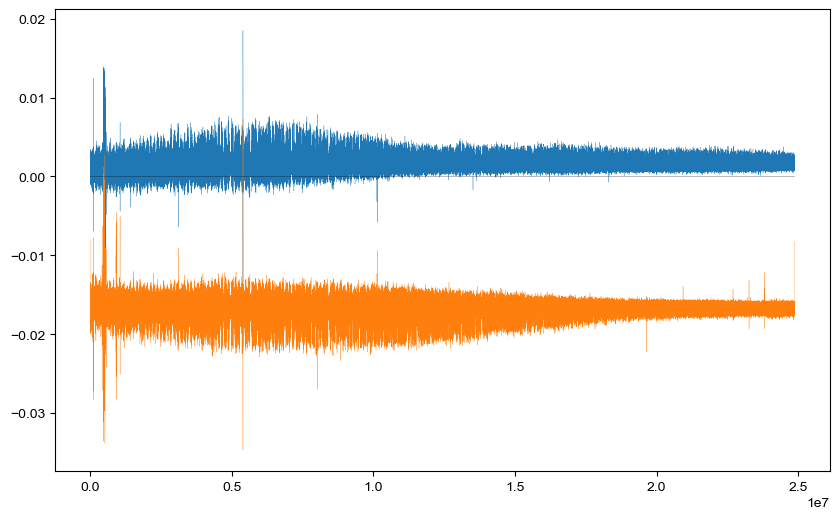

In [16]:
def plot_swim_signals(
    bh_ch0: np.ndarray, 
    bh_ch1: np.ndarray,
    visual_input: np.ndarray, 
    ax: Axes = None
):
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = plt.axes()
    
    ax.plot(bh_ch0, linewidth=0.2)
    ax.plot(-bh_ch1, linewidth=0.2)
    #ax.plot(ephyst[8]/35)
    ax.plot(visual_input/100000,'k', linewidth=0.2)
    #ax.set_ylim(-0.0001,0.0001)
    return ax

flt_ch0 = datas[0]['ch0']
flt_ch1 = datas[0]['ch1']
visual_input = datas[0]['drift']

def gaussian(x, mu, sigma):
    return np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

gkernel = gaussian(np.linspace(-5, 5, 101), 0, 20)
gkernel = gkernel / np.sum(gkernel)
smoothed_flt_ch0 = np.convolve(flt_ch0, gkernel, mode='same')
smoothed_flt_ch1 = np.convolve(flt_ch1, gkernel, mode='same')

plot_swim_signals(smoothed_flt_ch0, smoothed_flt_ch1, visual_input)
